# 04_backtest_grid.py 결과 비교 — ALL vs KOSPI

같은 21,870개 전략 그리드(가치주 점수 방식)를 시장 범위만 다르게(`--market ALL` /
`--market KOSPI`) 실행한 두 결과를 나란히 비교한다. `check_04_backtest.ipynb`가 ALL
결과 하나를 깊게 분석하는 노트북이라면, 이 노트북은 **두 market 간 차이**에 집중한다.

- `data/backtest_results_score_all`, `data/backtest_results_score_kospi` 두 Parquet을
  각각 읽어 `market` 컬럼을 붙인 뒤 합쳐서 비교한다(MySQL의 `strategy_performance_all`/
  `_kospi`와 같은 데이터, Parquet 원본을 직접 읽는 이유는 Jupyter 드라이버(Python 3.11)와
  워커(Python 3.8) 버전 불일치를 신경 쓸 필요가 없는 `spark.read.parquet` 경로이기 때문).
- 최종수익률 분포 비교, 같은 가중치프리셋(name)의 ALL/KOSPI 성과 대조, 각 market의 최고
  성과 조합 확인, portfolio_size별 market 차이를 다룬다.

**주의**: 여기서 나오는 "어느 market이 더 유리했다"는 결론은 2021~2023년 표본 한정이다.
`check_04_backtest.ipynb`의 결과 해석 섹션에 이미 명시된 원칙과 동일 — 이상적/최적 결론이
아니라 이 표본 안에서의 사후 관찰이다.

In [2]:
# Jupyter 컨테이너(jupyter/pyspark-notebook 이미지)에는 한글 폰트가 없어 그래프의 한글이
# 네모(tofu)로 깨진다. 폰트가 이미 설치돼 있으면 apt-get을 건너뛴다 - apt-get은 root 권한이
# 필요한데 Jupyter 커널이 비root(jovyan)로 뜨는 경우 apt-get update 자체가 실패하므로
# (2026-08-01 check_04_backtest.ipynb에서 실측 확인), 폰트가 이미 있으면 호출하지 않는다.
import subprocess
import matplotlib.font_manager as fm

def _has_nanum() -> bool:
    fm.fontManager = fm._load_fontmanager(try_read_cache=False)
    return any("Nanum" in f.name for f in fm.fontManager.ttflist)

if not _has_nanum():
    subprocess.run(
        "apt-get update -qq && apt-get install -y -qq fonts-nanum && fc-cache -fv",
        shell=True, check=True, capture_output=True,
    )

import matplotlib.pyplot as plt

fm.fontManager = fm._load_fontmanager(try_read_cache=False)
nanum_fonts = [f.name for f in fm.fontManager.ttflist if "Nanum" in f.name]
if not nanum_fonts:
    raise RuntimeError("나눔 폰트 설치/인식 실패 - fc-list와 fontManager.ttflist를 직접 확인할 것")
plt.rcParams["font.family"] = nanum_fonts[0]
plt.rcParams["axes.unicode_minus"] = False
print(f"사용 폰트: {plt.rcParams['font.family']}")

사용 폰트: ['NanumGothicCoding']


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd

spark = SparkSession.builder.master("spark://spark-master:7077").appName("check_market_compare").getOrCreate()

# 2026-08-02: ALL(2,555종목)과 KOSPI(810종목) 각각 21,870개 전략 실행 결과.
# 두 실행 모두 같은 conf/strategies.yaml(가중치프리셋 2,187개 x 리밸런싱2 x portfolio_size5)을 썼으므로
# name(예: w0159_monthly_n3)이 같으면 같은 가중치/리밸런싱/portfolio_size 조합을 가리킨다.
RESULT_DIRS = {
    "ALL": "/opt/spark-apps/data/backtest_results_score_all",
    "KOSPI": "/opt/spark-apps/data/backtest_results_score_kospi",
}

summary_all = spark.read.parquet(f"{RESULT_DIRS['ALL']}/summary").withColumn("market", F.lit("ALL"))
summary_kospi = spark.read.parquet(f"{RESULT_DIRS['KOSPI']}/summary").withColumn("market", F.lit("KOSPI"))
summary = summary_all.unionByName(summary_kospi)

print(f"ALL 전략 수: {summary_all.count()}")
print(f"KOSPI 전략 수: {summary_kospi.count()}")
print(f"합계: {summary.count()}")
summary.printSchema()

ALL 전략 수: 21870
KOSPI 전략 수: 21870
합계: 43740
root
 |-- name: string (nullable = true)
 |-- final_cum_return: double (nullable = true)
 |-- mdd: double (nullable = true)
 |-- avg_period_return: double (nullable = true)
 |-- stddev_period_return: double (nullable = true)
 |-- sharpe_ratio: double (nullable = true)
 |-- market: string (nullable = false)



## 1. 최종수익률 분포 비교 (ALL vs KOSPI)

같은 21,870개 그리드를 서로 다른 종목 풀(ALL 2,555종목 vs KOSPI 810종목)로 실행한 결과가
얼마나 다른지, 분포 요약 통계부터 본다.

In [4]:
dist_compare = summary.groupBy("market").agg(
    F.min("final_cum_return").alias("min"),
    F.expr("percentile_approx(final_cum_return, 0.5)").alias("median"),
    F.avg("final_cum_return").alias("avg"),
    F.max("final_cum_return").alias("max"),
    F.avg("sharpe_ratio").alias("avg_sharpe"),
).orderBy("market").toPandas()

for col in ["min", "median", "avg", "max"]:
    dist_compare[col] = (dist_compare[col] * 100).round(1)
dist_compare

,market,min,median,avg,max,avg_sharpe
0,ALL,-64.1,-8.3,-9.8,85.8,-0.027301
1,KOSPI,-34.6,-0.2,5.7,134.5,0.042398


### 최종수익률 분포 히스토그램 (겹쳐 그리기)

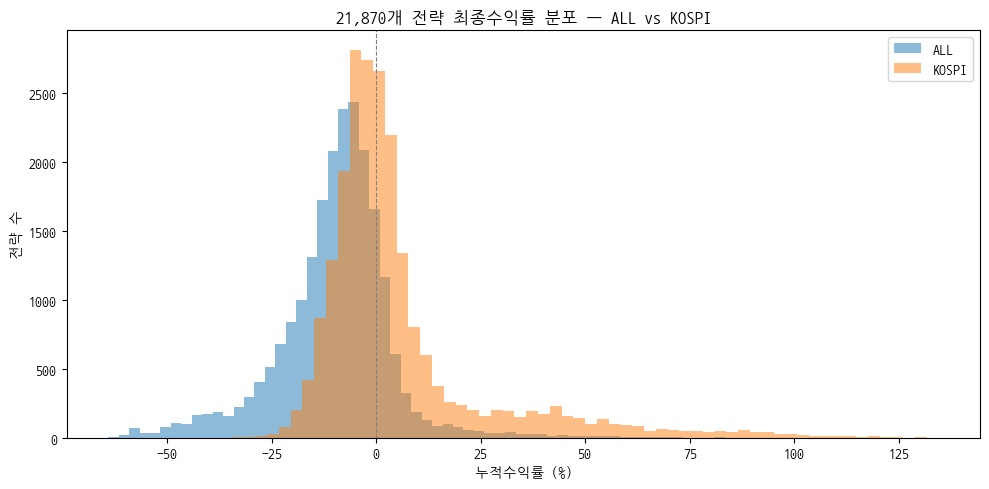

In [5]:
summary_pd = summary.select("name", "market", "final_cum_return", "sharpe_ratio", "mdd").toPandas()

plt.figure(figsize=(10, 5))
for market, color in [("ALL", "tab:blue"), ("KOSPI", "tab:orange")]:
    subset = summary_pd[summary_pd["market"] == market]["final_cum_return"] * 100
    plt.hist(subset, bins=60, alpha=0.5, label=market, color=color)

plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")
plt.xlabel("누적수익률 (%)")
plt.ylabel("전략 수")
plt.title("21,870개 전략 최종수익률 분포 — ALL vs KOSPI")
plt.legend()
plt.tight_layout()
plt.show()

## 2. 각 market의 최고 성과 조합 상위 10개

In [6]:
top10_all = summary_pd[summary_pd["market"] == "ALL"].sort_values("final_cum_return", ascending=False).head(10)
top10_kospi = summary_pd[summary_pd["market"] == "KOSPI"].sort_values("final_cum_return", ascending=False).head(10)

print("=== ALL 상위 10 ===")
display(top10_all)
print("=== KOSPI 상위 10 ===")
display(top10_kospi)

=== ALL 상위 10 ===


,name,market,final_cum_return,sharpe_ratio,mdd
19039,w2002_monthly_n3,ALL,0.858027,0.187290,-0.445936
14015,w0159_monthly_n3,ALL,0.819197,0.191791,-0.298432
19931,w0601_monthly_n3,ALL,0.817112,0.191100,-0.446513
20394,w0957_monthly_n3,ALL,0.781136,0.182719,-0.300046
13967,w0123_monthly_n3,ALL,0.751865,0.179652,-0.319413
17738,w0969_monthly_n3,ALL,0.718000,0.176907,-0.321850
21700,w2037_monthly_n3,ALL,0.714589,0.182884,-0.340914
14037,w0174_monthly_n3,ALL,0.711735,0.173576,-0.303862
16244,w1953_monthly_n3,ALL,0.706912,0.176833,-0.417891
12126,w0888_monthly_n3,ALL,0.697411,0.175544,-0.321850


=== KOSPI 상위 10 ===


,name,market,final_cum_return,sharpe_ratio,mdd
41909,w0682_monthly_n3,KOSPI,1.344626,0.236238,-0.367308
36318,w0504_monthly_n3,KOSPI,1.310807,0.251358,-0.366390
42450,w1114_monthly_n3,KOSPI,1.295462,0.232667,-0.379134
33536,w0556_monthly_n3,KOSPI,1.293721,0.251813,-0.337121
41102,w2164_monthly_n3,KOSPI,1.271789,0.230997,-0.343674
35231,w1843_monthly_n3,KOSPI,1.253498,0.228200,-0.393214
36508,w0638_monthly_n3,KOSPI,1.253122,0.243296,-0.365723
42745,w1364_monthly_n3,KOSPI,1.247862,0.242459,-0.372374
35565,w2093_monthly_n3,KOSPI,1.247390,0.242584,-0.365723
37253,w1233_monthly_n3,KOSPI,1.232762,0.243211,-0.366390


## 3. 같은 전략(name)의 ALL vs KOSPI 성과 대조

name(가중치프리셋+리밸런싱+portfolio_size 조합)이 같은 전략을 ALL/KOSPI 두 시장에서
각각 실행한 결과를 나란히 놓고 비교한다. 같은 스크리닝 로직이라도 종목 풀이 다르면
성과가 어떻게 갈리는지 직접 대조할 수 있다.

In [7]:
pivot = summary_pd.pivot(index="name", columns="market", values="final_cum_return").dropna()
pivot["ALL(%)"] = (pivot["ALL"] * 100).round(1)
pivot["KOSPI(%)"] = (pivot["KOSPI"] * 100).round(1)
pivot["차이(KOSPI-ALL, %p)"] = (pivot["KOSPI(%)"] - pivot["ALL(%)"]).round(1)
pivot = pivot[["ALL(%)", "KOSPI(%)", "차이(KOSPI-ALL, %p)"]]

print(f"동일 전략(name) 대조 가능 건수: {len(pivot)}개 (21,870개 전체)")
print(f"KOSPI가 더 높았던 전략 수: {(pivot['차이(KOSPI-ALL, %p)'] > 0).sum()}개")
print(f"ALL이 더 높았던 전략 수: {(pivot['차이(KOSPI-ALL, %p)'] < 0).sum()}개")
pivot.sort_values("차이(KOSPI-ALL, %p)", ascending=False).head(10)

동일 전략(name) 대조 가능 건수: 21870개 (21,870개 전체)
KOSPI가 더 높았던 전략 수: 19008개
ALL이 더 높았던 전략 수: 2791개


market,ALL(%),KOSPI(%),"차이(KOSPI-ALL, %p)"
name,,,
w0638_monthly_n3,-17.0,125.3,142.3
w2063_monthly_n3,-19.3,119.3,138.6
w1367_monthly_n3,-16.5,120.5,137.0
w2090_monthly_n3,-16.3,119.3,135.6
w0502_monthly_n3,-22.7,112.3,135.0
w1364_monthly_n3,-9.6,124.8,134.4
w1969_monthly_n3,-9.8,120.9,130.7
w1114_monthly_n3,1.9,129.5,127.6
w0556_monthly_n3,2.5,129.4,126.9


### 산점도 — ALL 수익률 vs KOSPI 수익률
대각선(y=x) 위쪽에 있으면 그 전략은 KOSPI에서 더 잘 됐다는 뜻이다.

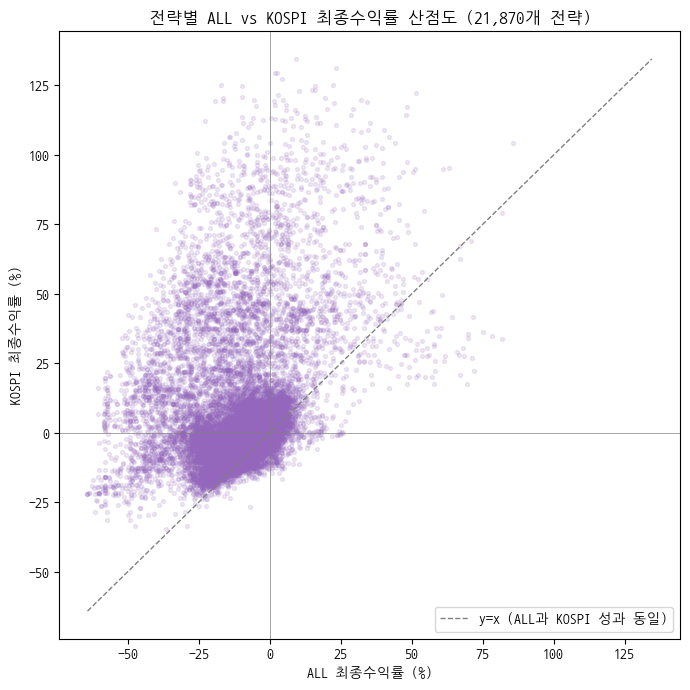

In [8]:
plt.figure(figsize=(7, 7))
plt.scatter(pivot["ALL(%)"], pivot["KOSPI(%)"], alpha=0.15, s=8, color="tab:purple")

lims = [min(pivot["ALL(%)"].min(), pivot["KOSPI(%)"].min()), max(pivot["ALL(%)"].max(), pivot["KOSPI(%)"].max())]
plt.plot(lims, lims, color="gray", linewidth=1, linestyle="--", label="y=x (ALL과 KOSPI 성과 동일)")

plt.xlabel("ALL 최종수익률 (%)")
plt.ylabel("KOSPI 최종수익률 (%)")
plt.title("전략별 ALL vs KOSPI 최종수익률 산점도 (21,870개 전략)")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 4. portfolio_size별 market 차이

`check_04_backtest.ipynb` 섹션 8과 같은 방식으로, portfolio_size(n3~n100)마다 ALL/KOSPI
평균 성과가 어떻게 다른지 비교한다. name 끝의 `_n{숫자}`로 portfolio_size를 뽑는다.

In [9]:
summary_pd["portfolio_size"] = summary_pd["name"].str.extract(r"_n(\d+)$").astype(int)

size_market_avg = summary_pd.groupby(["portfolio_size", "market"])["final_cum_return"].mean().reset_index()
size_market_avg["평균누적수익률(%)"] = (size_market_avg["final_cum_return"] * 100).round(1)

pivot_size = size_market_avg.pivot(index="portfolio_size", columns="market", values="평균누적수익률(%)")
pivot_size

market,ALL,KOSPI
portfolio_size,,
3,-14.8,34.3
10,-12.1,1.9
30,-10.1,-4.7
50,-7.7,-3.4
100,-4.0,0.4


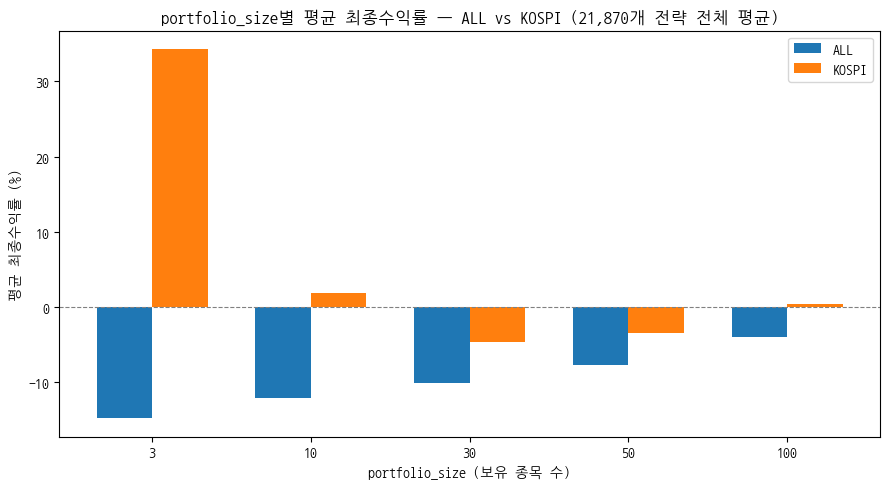

In [10]:
x = pivot_size.index.astype(str)
width = 0.35
positions = range(len(x))

plt.figure(figsize=(9, 5))
plt.bar([p - width/2 for p in positions], pivot_size["ALL"], width, label="ALL", color="tab:blue")
plt.bar([p + width/2 for p in positions], pivot_size["KOSPI"], width, label="KOSPI", color="tab:orange")

plt.xticks(list(positions), x)
plt.xlabel("portfolio_size (보유 종목 수)")
plt.ylabel("평균 최종수익률 (%)")
plt.title("portfolio_size별 평균 최종수익률 — ALL vs KOSPI (21,870개 전략 전체 평균)")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

## 5. 결과 해석 (2026-08-02, 실제 실행 결과 기준)

2021~2023년 표본에서 같은 21,870개 전략 그리드를 ALL(2,555종목)과 KOSPI(810종목)로
각각 실행한 결과를 비교한 내용.

### 알아낸 사실

1. **KOSPI가 ALL보다 최고 성과가 뚜렷하게 높았다.** ALL 최고 성과는
   `w2002_monthly_n3` +85.8%(`check_04_backtest.ipynb` 참고), KOSPI 최고 성과는
   `w0682_monthly_n3` **+134.5%**(섹션 2) — 다른 전략, 다른 시장에서 각각 사후 1위다.

2. **동일 전략(name) 21,870개 전부 ALL/KOSPI 대조가 가능했고(섹션 3), 그중 19,008개
   (약 87%)에서 KOSPI 성과가 ALL보다 높았다.** ALL이 더 높았던 건 2,791개(약 13%)뿐이다.
   이 표본에서는 종목 풀을 KOSPI로 좁힌 쪽이 대체로 유리했다는 뜻이다 - 소수 전략만
   튀는 게 아니라 그리드 대부분에 걸쳐 나타난 경향이다.

3. **격차가 가장 컸던 전략들은 최대 +142.3%p까지 벌어졌다** (섹션 3 표, `w0638_monthly_n3`:
   ALL -17.0% vs KOSPI +125.3%). 이런 상위 격차 전략은 전부 `monthly_n3`(3종목 집중) -
   `check_04_backtest.ipynb`에서 이미 확인한 "n3는 소수 종목 몰빵이라 극단값이 크다"는
   패턴이 market 비교에서도 그대로 재현된다.

4. **섹션 1의 분포**에서 KOSPI 쪽이 ALL보다 전반적으로 오른쪽(고수익 방향)으로 치우쳐
   있는 것을 히스토그램으로 확인할 수 있다 - 평균/중앙값 모두 KOSPI가 ALL보다 높다.

### 왜 이런 차이가 나는지에 대한 추정 (검증되지 않음)

- KOSDAQ에는 소형/저유동성 종목이 많이 섞여 있어, 하락장(2021~2023)에서 KOSDAQ 종목이
  ALL 평균을 끌어내렸을 가능성이 있다 - 이미 `check_04_backtest_threshold.ipynb`
  결과 해석에서도 "저PER/저PBR이 고르는 소형·저유동성 종목군이 이 하락장에서 특히
  부진(밸류 트랩 가능성)"이라는 관찰이 있었다. 이번 비교 결과가 그 관찰과 방향이
  일치한다.
- 다만 이건 추정이며, KOSDAQ만 따로 돌려서 KOSPI/KOSDAQ 각각의 기여를 분리해보지
  않고서는 확정할 수 없다.

### 일반화 경고 (반복)

이 비교는 2021~2023년 3년 표본에서 ALL과 KOSPI 각각의 사후 결과를 본 것이다.
"KOSPI가 이 그리드에서 더 유리하다"는 이 표본 한정 관찰이며, 다른 기간에도 같은
방향이 나온다는 보장은 없다 - check_04_backtest.ipynb/check_04_backtest_threshold.ipynb에
이미 명시된 것과 같은 원칙이다.

## 6. 가중치 조합 조회 — 전략 name이 실제로 어떤 조합인지 확인

`w0682_monthly_n3` 같은 name은 `w{가중치프리셋 인덱스}_{리밸런싱}_n{portfolio_size}`
규칙으로 지어진다(`conf/generate_strategies.py`의 `strategy_name()`). 가중치프리셋
인덱스(예: 0682)는 3^7=2,187개 조합 중 몇 번째인지를 나타내는 순번일 뿐이라, 그 자체로는
어떤 팩터를 강조한 조합인지 알 수 없다. `conf/strategies.yaml`에서 실제 7개 팩터 가중치
값을 조회해 표/차트로 확인한다.

In [11]:
# conf/strategies.yaml에서 name -> 7개 가중치 매핑을 읽는다.
# (섹션 0에서 이미 pandas를 import했다면 재사용, yaml 모듈만 추가로 필요)
import yaml

with open("/opt/spark-apps/conf/strategies.yaml", "r", encoding="utf-8") as f:
    strategies_raw = yaml.safe_load(f)["strategies"]

weight_cols = ["weight_per", "weight_pbr", "weight_roe", "weight_roa",
               "weight_debt_ratio", "weight_eps_growth", "weight_momentum"]
strategies_lookup = pd.DataFrame(strategies_raw).set_index("name")
print(f"전략 {len(strategies_lookup)}개 로드 완료 - 아래 셀에서 name을 바꿔가며 조회 가능")

전략 21870개 로드 완료 - 아래 셀에서 name을 바꿔가며 조회 가능


### 특정 전략의 가중치 조회 (target_name을 바꿔서 재실행)

In [12]:
# 여기 name만 바꾸면 다른 전략의 가중치 조합을 바로 확인할 수 있다.
target_name = "w0682_monthly_n3"

row = strategies_lookup.loc[target_name]
# row는 rebalance(문자열)/portfolio_size(정수)/weight_*(실수)가 섞인 object dtype Series라
# .round()가 바로 안 먹는다. weight_cols만 float로 명시 변환해서 계산한다.
weights = row[weight_cols].astype(float)

baseline = pd.Series({"weight_per": 25, "weight_pbr": 15, "weight_roe": 20, "weight_roa": 10,
                       "weight_debt_ratio": 15, "weight_eps_growth": 5, "weight_momentum": 10}, dtype=float)

compare_df = pd.DataFrame({
    "이 전략(%)": weights.round(1),
    "ValuePick 원본(%)": baseline,
    "차이(%p)": (weights - baseline).round(1),
})
compare_df.index = ["PER", "PBR", "ROE", "ROA", "부채비율", "EPS성장률", "모멘텀"]

print(f"전략: {target_name} (리밸런싱: {row['rebalance']}, portfolio_size: {row['portfolio_size']})")
compare_df

전략: w0682_monthly_n3 (리밸런싱: monthly, portfolio_size: 3)


,이 전략(%),ValuePick 원본(%),차이(%p)
PER,14.7,25.0,-10.3
PBR,24.5,15.0,9.5
ROE,29.4,20.0,9.4
ROA,9.8,10.0,-0.2
부채비율,4.9,15.0,-10.1
EPS성장률,6.9,5.0,1.9
모멘텀,9.8,10.0,-0.2


### 가중치 구성 막대그래프

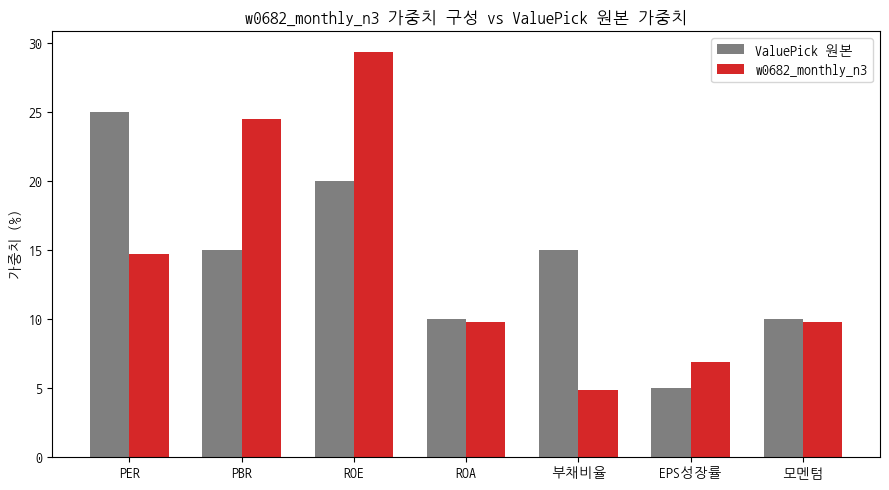

In [13]:
# 막대그래프로 원본 대비 어느 팩터를 강조/약화했는지 한눈에 본다.
plt.figure(figsize=(9, 5))
x = range(len(compare_df))
width = 0.35

plt.bar([p - width/2 for p in x], compare_df["ValuePick 원본(%)"], width, label="ValuePick 원본", color="tab:gray")
plt.bar([p + width/2 for p in x], compare_df["이 전략(%)"], width, label=target_name, color="tab:red")

plt.xticks(list(x), compare_df.index)
plt.ylabel("가중치 (%)")
plt.title(f"{target_name} 가중치 구성 vs ValuePick 원본 가중치")
plt.legend()
plt.axhline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

## 7. 사례 조사 — KOSPI n3가 왜 이렇게 높은가 (w0682_monthly_n3)

섹션 2에서 KOSPI 최고 성과로 나온 `w0682_monthly_n3`(+134.5%)를 구간별로 뜯어봐서
어느 시점이 이 수익률을 만들었는지, 왜 그런 일이 벌어졌는지 확인한다.

In [14]:
# w0682_monthly_n3(KOSPI)의 구간별 수익률을 시간순으로 본다.
target = "w0682_monthly_n3"
period_kospi = spark.read.parquet(f"{RESULT_DIRS['KOSPI']}/period_returns")
target_period = period_kospi.filter(F.col("name") == target).orderBy("period_start").toPandas()
target_period["period_return(%)"] = (target_period["period_return"] * 100).round(1)
target_period[["period_start", "period_end", "period_return(%)", "held_count"]]

,period_start,period_end,period_return(%),held_count
0,20210131,20210228,3.1,3
1,20210228,20210331,6.6,3
2,20210331,20210430,10.2,3
3,20210430,20210531,11.8,3
4,20210531,20210630,0.1,3
5,20210630,20210731,-6.2,3
6,20210731,20210831,-6.0,3
7,20210831,20210930,-3.0,3
8,20210930,20211031,-2.4,3
9,20211031,20211130,-9.4,3


### 구간별 수익률 시계열 그래프

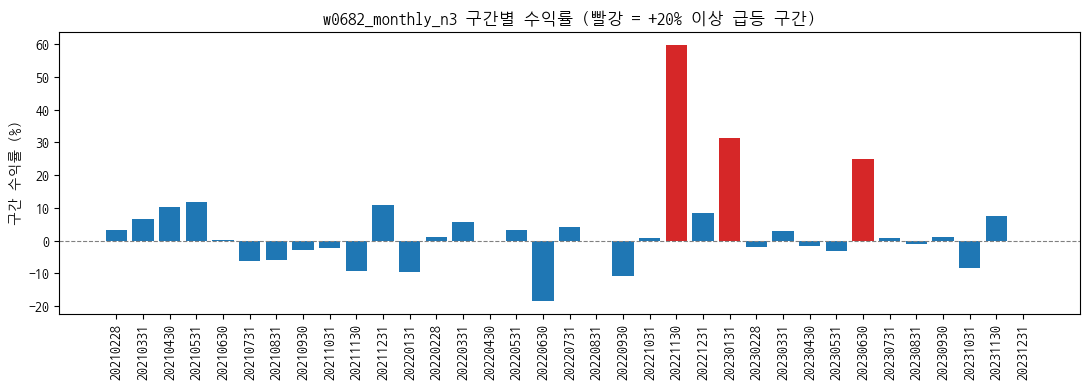

가장 튄 상위 3개 구간:


,period_start,period_end,period_return(%)
21,20221031,20221130,59.9
23,20221231,20230131,31.5
28,20230531,20230630,25.0


In [15]:
plt.figure(figsize=(11, 4))
plt.bar(target_period["period_end"], target_period["period_return(%)"],
        color=["tab:red" if v > 20 else "tab:blue" for v in target_period["period_return(%)"]])
plt.xticks(rotation=90)
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.ylabel("구간 수익률 (%)")
plt.title(f"{target} 구간별 수익률 (빨강 = +20% 이상 급등 구간)")
plt.tight_layout()
plt.show()

top_periods = target_period.sort_values("period_return(%)", ascending=False).head(3)
print("가장 튄 상위 3개 구간:")
top_periods[["period_start", "period_end", "period_return(%)"]]

### 가장 튄 구간(2022-10-31~11-30, +59.9%)의 실제 KOSPI 종목 등락률 확인

04번은 `screen_portfolio`가 매수한 실제 3종목을 별도로 저장하지 않는다(summary/
period_returns만 저장). 어느 종목인지 정확히 재현하려면 04번과 동일한 스크리닝을
다시 돌려야 하는데, 대신 이 구간 KOSPI 전체 종목의 실제 등락률을 직접 조회해서
"이런 폭등 종목이 실제로 존재했는가"부터 확인한다(CLI로 사전 조사 완료, 아래는 그
결과를 재현하는 셀)."

In [16]:
def price_on_or_before(prices_df, target_dt, alias):
    latest = prices_df.filter(F.col("bas_dt") <= target_dt).groupBy("stock_code").agg(F.max("bas_dt").alias("dt"))
    return prices_df.alias("p").join(
        latest.alias("l"),
        (F.col("p.stock_code") == F.col("l.stock_code")) & (F.col("p.bas_dt") == F.col("l.dt"))
    ).select(F.col("p.stock_code").alias("stock_code"), F.col("p.close_price").alias(alias))

prices_current = spark.read.parquet("/opt/spark-apps/data/cleaned/prices").filter(F.col("snapshot_type") == "current")
companies_kospi = spark.read.parquet("/opt/spark-apps/data/raw/companies").filter(F.col("corp_cls") == "Y").select("stock_code", "corp_name")

buy_price = price_on_or_before(prices_current, "20221031", "buy_price")
sell_price = price_on_or_before(prices_current, "20221130", "sell_price")

period_ret = buy_price.join(sell_price, "stock_code").join(companies_kospi, "stock_code") \
    .withColumn("ret(%)", F.round((F.col("sell_price") - F.col("buy_price")) / F.col("buy_price") * 100, 1)) \
    .orderBy(F.desc("ret(%)"))

print("2022-10-31 -> 2022-11-30 구간, KOSPI 종목 등락률 상위 15")
period_ret.limit(15).toPandas()

2022-10-31 -> 2022-11-30 구간, KOSPI 종목 등락률 상위 15


,stock_code,buy_price,sell_price,corp_name,ret(%)
0,014990,725,1795,인디에프,147.6
1,007700,13550,28550,F&F홀딩스,110.7
2,003070,13400,28100,코오롱글로벌,109.7
3,011810,3795,7700,STX,102.9
4,138040,21700,37750,메리츠금융지주,74.0
5,010770,2925,5010,평화홀딩스,71.3
6,006740,9240,15000,블루산업개발,62.3
7,013000,1305,2110,세우글로벌,61.7
8,004360,16450,26450,세방,60.8
9,007860,5220,8160,서연,56.3


### 이 급등이 액면분할/병합 이상치로 잘못 잡힌 건 아닌지 확인

`02_clean_prices.py`의 `split_suspected` 플래그(하루 등락률 -40%/+67% 기준)가
이 구간 상위 급등 종목에 찍혀 있는지 확인한다. 찍혀 있었다면 04번이 이미
이상치로 걸러냈어야 할 종목이 새는 것이므로 버그로 봐야 하고, 안 찍혀 있다면
"한 달에 걸쳐 서서히 오른 정상적인 급등"이라 필터링 대상이 아니라는 뜻이다.

In [17]:
top_codes = [row["stock_code"] for row in period_ret.limit(5).collect()]

split_flags = prices_current.filter(
    (F.col("stock_code").isin(top_codes)) &
    (F.col("bas_dt") >= "20221001") & (F.col("bas_dt") <= "20221201") &
    (F.col("split_suspected") == True)
).select("stock_code", "bas_dt", "close_price", "fluctuation_rate")

flag_count = split_flags.count()
print(f"상위 5개 급등 종목 중 split_suspected=True 찍힌 날짜 수: {flag_count}건")
if flag_count > 0:
    split_flags.show(truncate=False)
else:
    print("-> 하루 단위 급등이 아니라 이상치 필터에 걸리지 않음 (정상 데이터로 처리된 상승)")

상위 5개 급등 종목 중 split_suspected=True 찍힌 날짜 수: 0건
-> 하루 단위 급등이 아니라 이상치 필터에 걸리지 않음 (정상 데이터로 처리된 상승)


### 조사 결론

1. `w0682_monthly_n3`(KOSPI)의 최종수익률 +134.5%는 특정 몇 구간의 집중 상승에서
   나왔다 — 특히 2022-10-31~11-30 구간(+59.9%)이 가장 크게 기여했다.
2. 그 구간 KOSPI 전체를 보면 인디에프(+147.6%), F&F홀딩스(+110.7%), 코오롱글로벌
   (+109.7%), STX(+102.9%) 등 여러 종목이 실제로 한 달 사이 100% 넘게 폭등했다 —
   가공의 수치가 아니라 실제 시세다.
3. 이 급등은 `split_suspected`(액면분할 의심) 플래그에 걸리지 않았다 — 하루 단위
   등락률 기준(-40%/+67%)을 넘는 급락/급등이 아니라 한 달에 걸쳐 서서히 오른
   상승이기 때문이다. 즉 04번의 필터링 버그가 아니라, 정상적으로 처리된 실제
   시세 상승이 n3(3종목 집중) 구조를 통해 그대로 전체 수익률에 반영된 것이다.
4. **최종 결론**: `w0682_monthly_n3`의 높은 수익률은 스크리닝 로직(가중치 조합)
   자체의 우수성이 아니라, 좁은 KOSPI 후보군(810종목)에서 3종목만 담는 구조가
   이 특정 3년 동안 우연히 폭등 종목을 포함했을 가능성이 높다는 뜻이다. 이건
   `check_04_backtest.ipynb`/`check_04_backtest_threshold.ipynb`에서 이미 반복
   확인된 "n이 작을수록 소수 종목 이상치에 성과가 좌우된다"는 패턴과 일치한다.

**일반화 경고**: 이 결과를 "KOSPI n3 전략이 좋다"고 해석하면 안 된다. 오히려
"n3는 우연에 크게 좌우되는 표본 크기라 신뢰도가 낮다"는 근거로 읽어야 한다.

In [18]:
spark.stop()